In [1]:
import os
import pandas as pd
import json

In [2]:
results_dir = "../benchmark/results"
macro_cmc_results = os.path.join(results_dir, "macro_cmc")
micro_cmc_results = os.path.join(results_dir, "micro_cmc")
model_nparams = os.path.join(results_dir, "openclip_model_nparams.json")

In [3]:
with open(model_nparams, "r") as f:
    nparams = json.load(f)

organized_model_nparams = {"vision_model": [], "pretrained_on": [], "nparams": []}
for model_ckp, nparam in nparams.items():
    model_info = model_ckp.split("/")[-1].split("--")
    vision_model = model_info[0]
    pretrained_on = model_info[1]

    organized_model_nparams["vision_model"].append(vision_model)
    organized_model_nparams["pretrained_on"].append(pretrained_on)
    organized_model_nparams["nparams"].append(nparam)

df_nparams = pd.DataFrame(organized_model_nparams)    

In [4]:
df_nparams

,vision_model,pretrained_on,nparams
0,RN50,openai,102007137
1,RN50,yfcc15m,102007137
2,RN50,cc12m,102007137
3,RN101,openai,119688033
4,RN101,yfcc15m,119688033
...,...,...,...
185,ViT-H-14-quickgelu,metaclip_fullcc,986109441
186,ViT-H-14-quickgelu,dfn5b,986109441
187,ViT-H-14-378-quickgelu,dfn5b,986714881
188,ViT-bigG-14-quickgelu,metaclip_fullcc,2539567105


Max nparams: 5,044,889,089
Min nparams: 62,469,185
Mean nparams: 623,397,335.5578947
Median nparams: 375,651,842.0


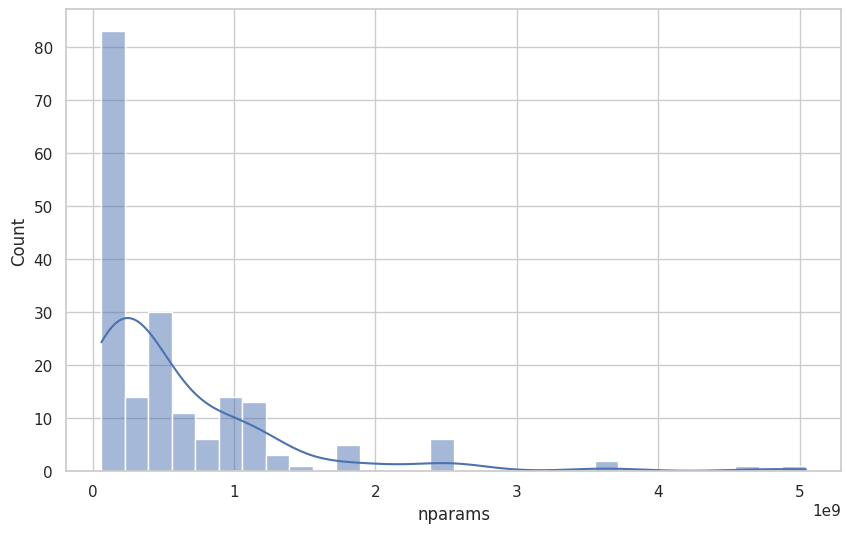

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Group the models based on the number of parameters
print(f"Max nparams: {df_nparams['nparams'].max():,}")
print(f"Min nparams: {df_nparams['nparams'].min():,}")
print(f"Mean nparams: {df_nparams['nparams'].mean():,}")
print(f"Median nparams: {df_nparams['nparams'].median():,}")

# Histogram of nparams
sns.histplot(df_nparams['nparams'], bins=30, kde=True)

# Use a quantile-based grouping for better distribution
df_nparams['nparams_group'] = pd.qcut(df_nparams['nparams'], q=4, labels=["Small", "Medium", "Large", "Very Large"])

## QUANTILE-BASED GROUPING
# Get the quantile edges
quantile_edges = pd.qcut(df_nparams['nparams'], q=4).unique()

In [6]:
quantile_edges

[(62469184.999, 151277313.0], (151277313.0, 375651842.0], (375651842.0, 881772546.0], (881772546.0, 5044889089.0]]
Categories (4, interval[float64, right]): [(62469184.999, 151277313.0] < (151277313.0, 375651842.0] < (375651842.0, 881772546.0] < (881772546.0, 5044889089.0]]

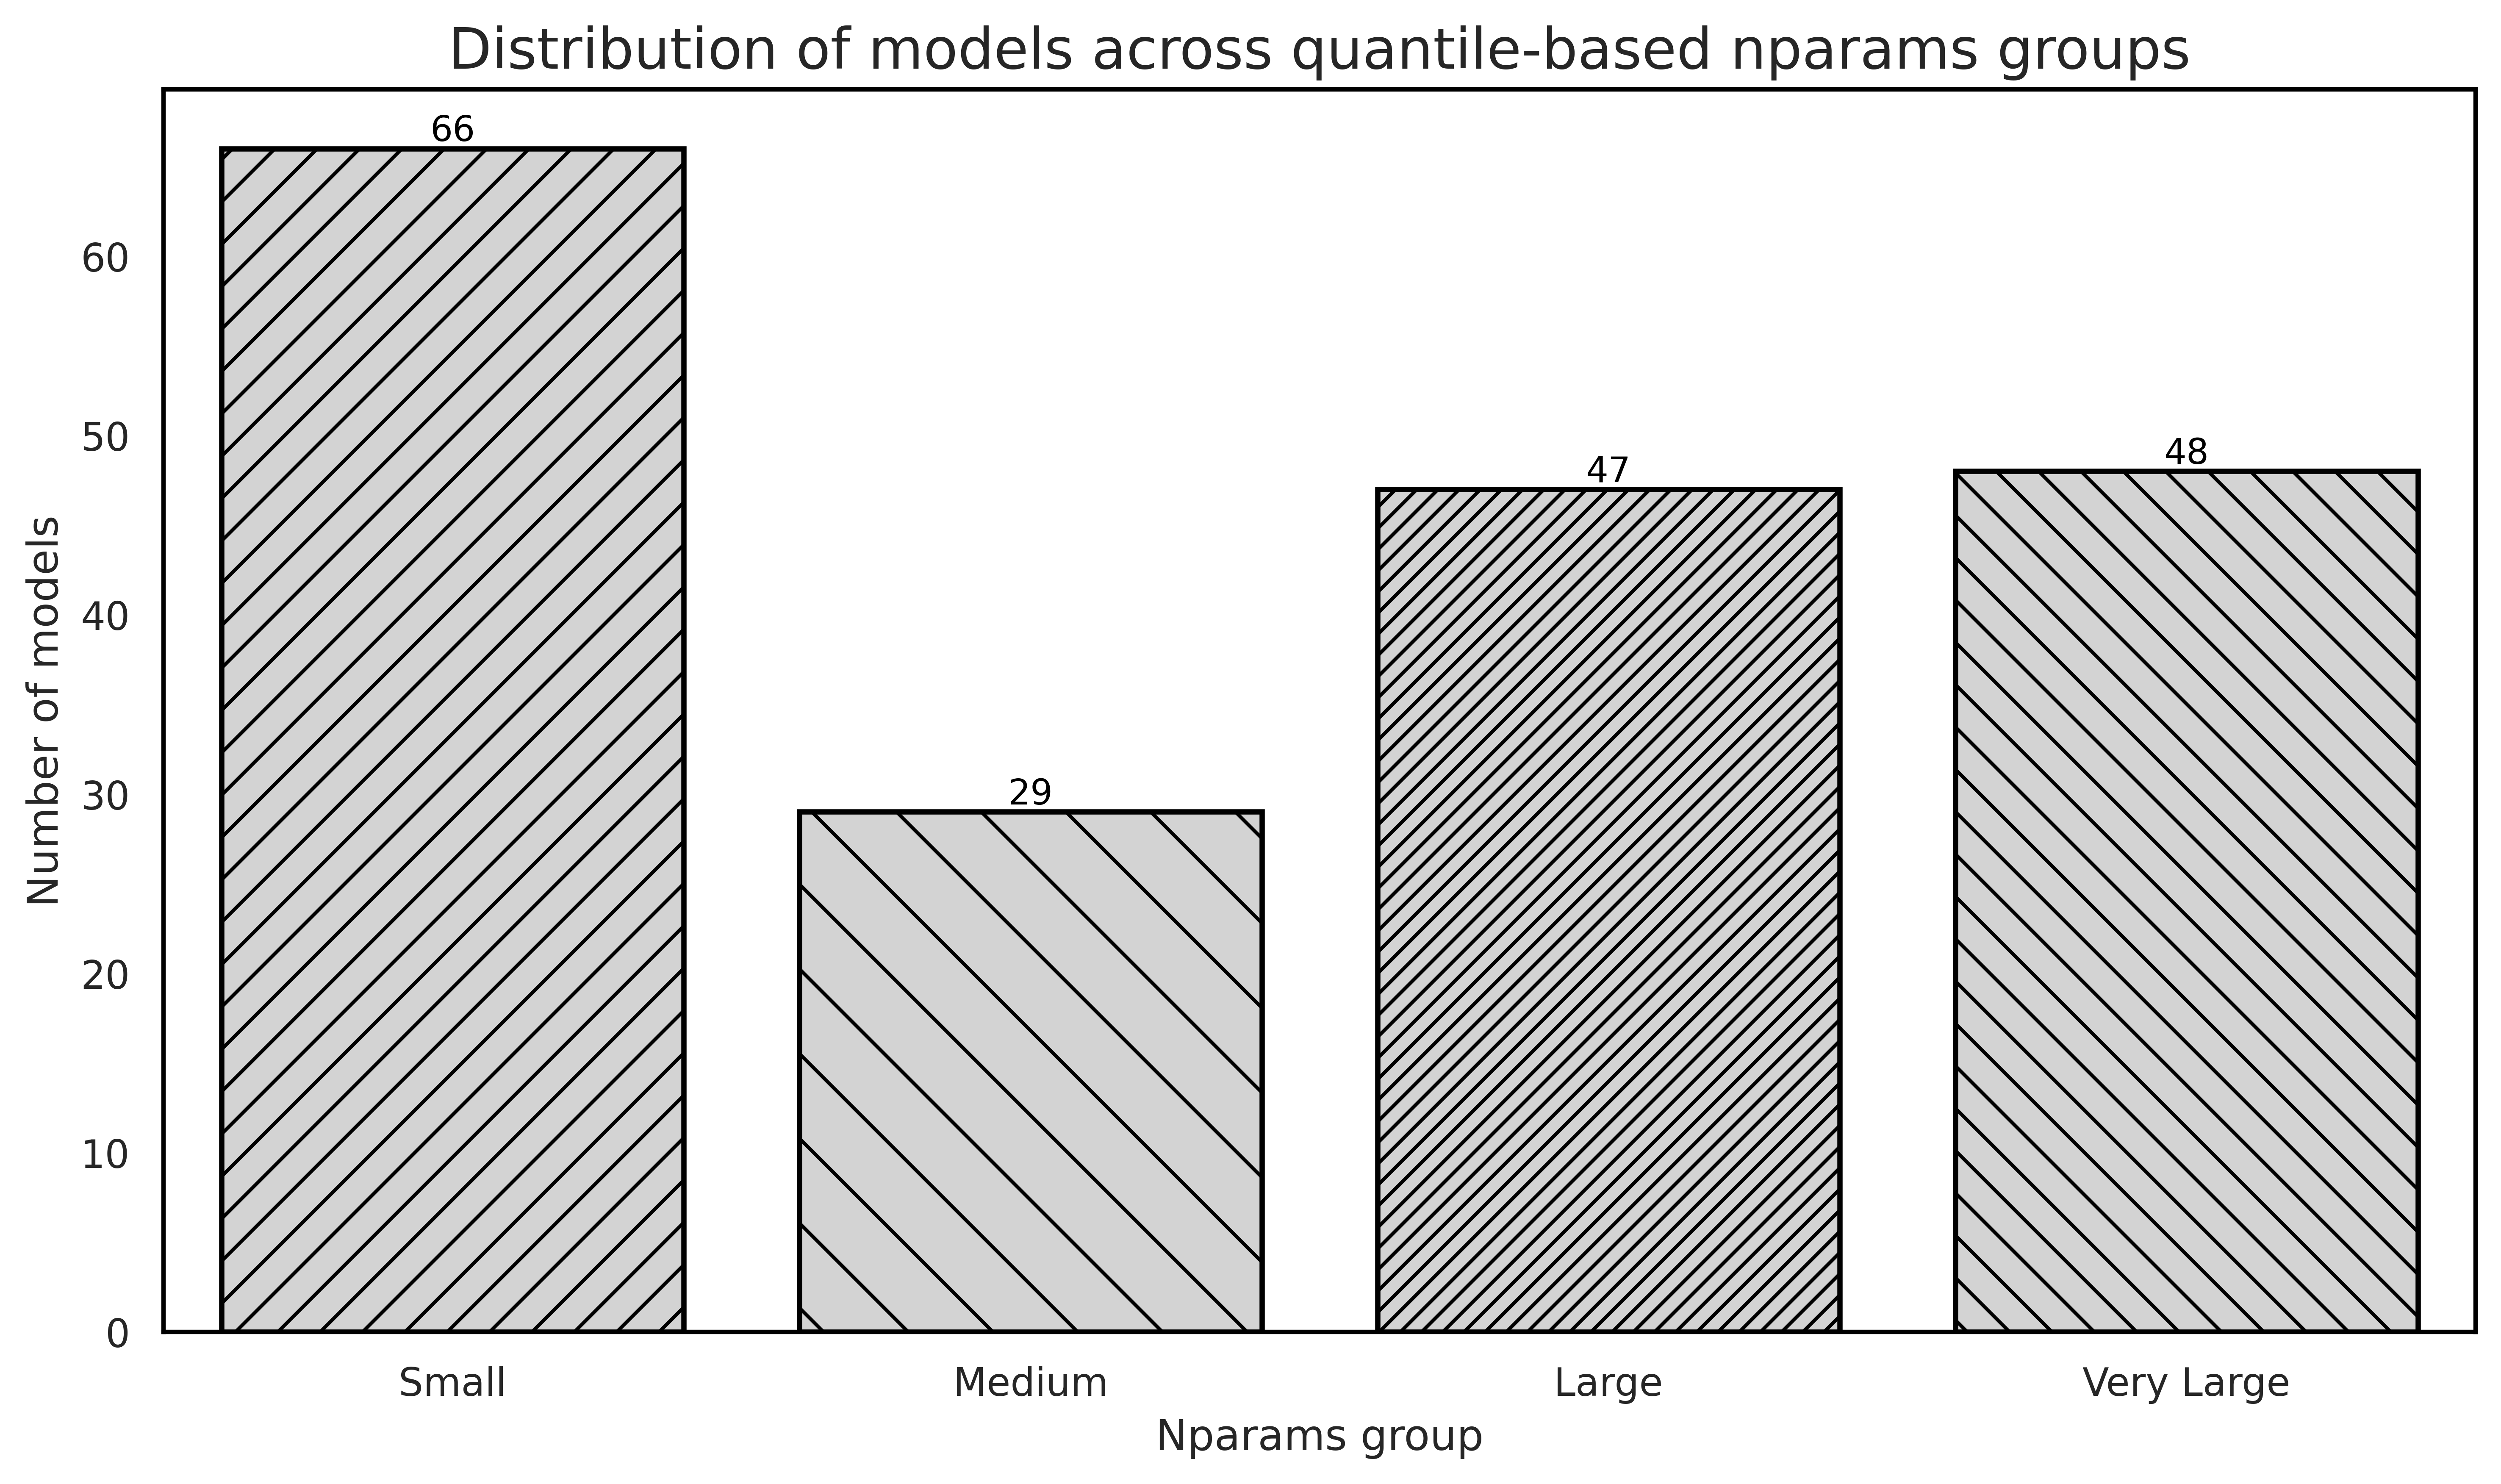

In [7]:
# Distribution of models across quantile-based nparams groups using a bar plot
plt.figure(figsize=(10, 6), dpi=600)
sns.countplot(x='nparams_group', data=df_nparams, order=["Small", "Medium", "Large", "Very Large"])
# Make the edges of the bars thicker
for bar in plt.gca().patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1.5)
# Make the grid lines disappear
plt.grid(False)
# Make the corners of plots color black
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
# Add value labels on top of each bar make it integer
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')
# Instead of filling the bars, use a hatch pattern unique to each bar
for i, bar in enumerate(plt.gca().patches):
    hatch_pattern = '//' if i % 2 == 0 else '\\'
    # Increase the density of the hatch pattern for higher quantiles
    hatch_pattern *= (i // 2 + 1)
    bar.set_hatch(hatch_pattern)
# Turn the colors of the bars to a light gray
for bar in plt.gca().patches:
    bar.set_facecolor('lightgray')


plt.title('Distribution of models across quantile-based nparams groups', fontsize=16)
plt.xlabel('Nparams group')
plt.ylabel('Number of models')

plt.tight_layout()
plt.show()

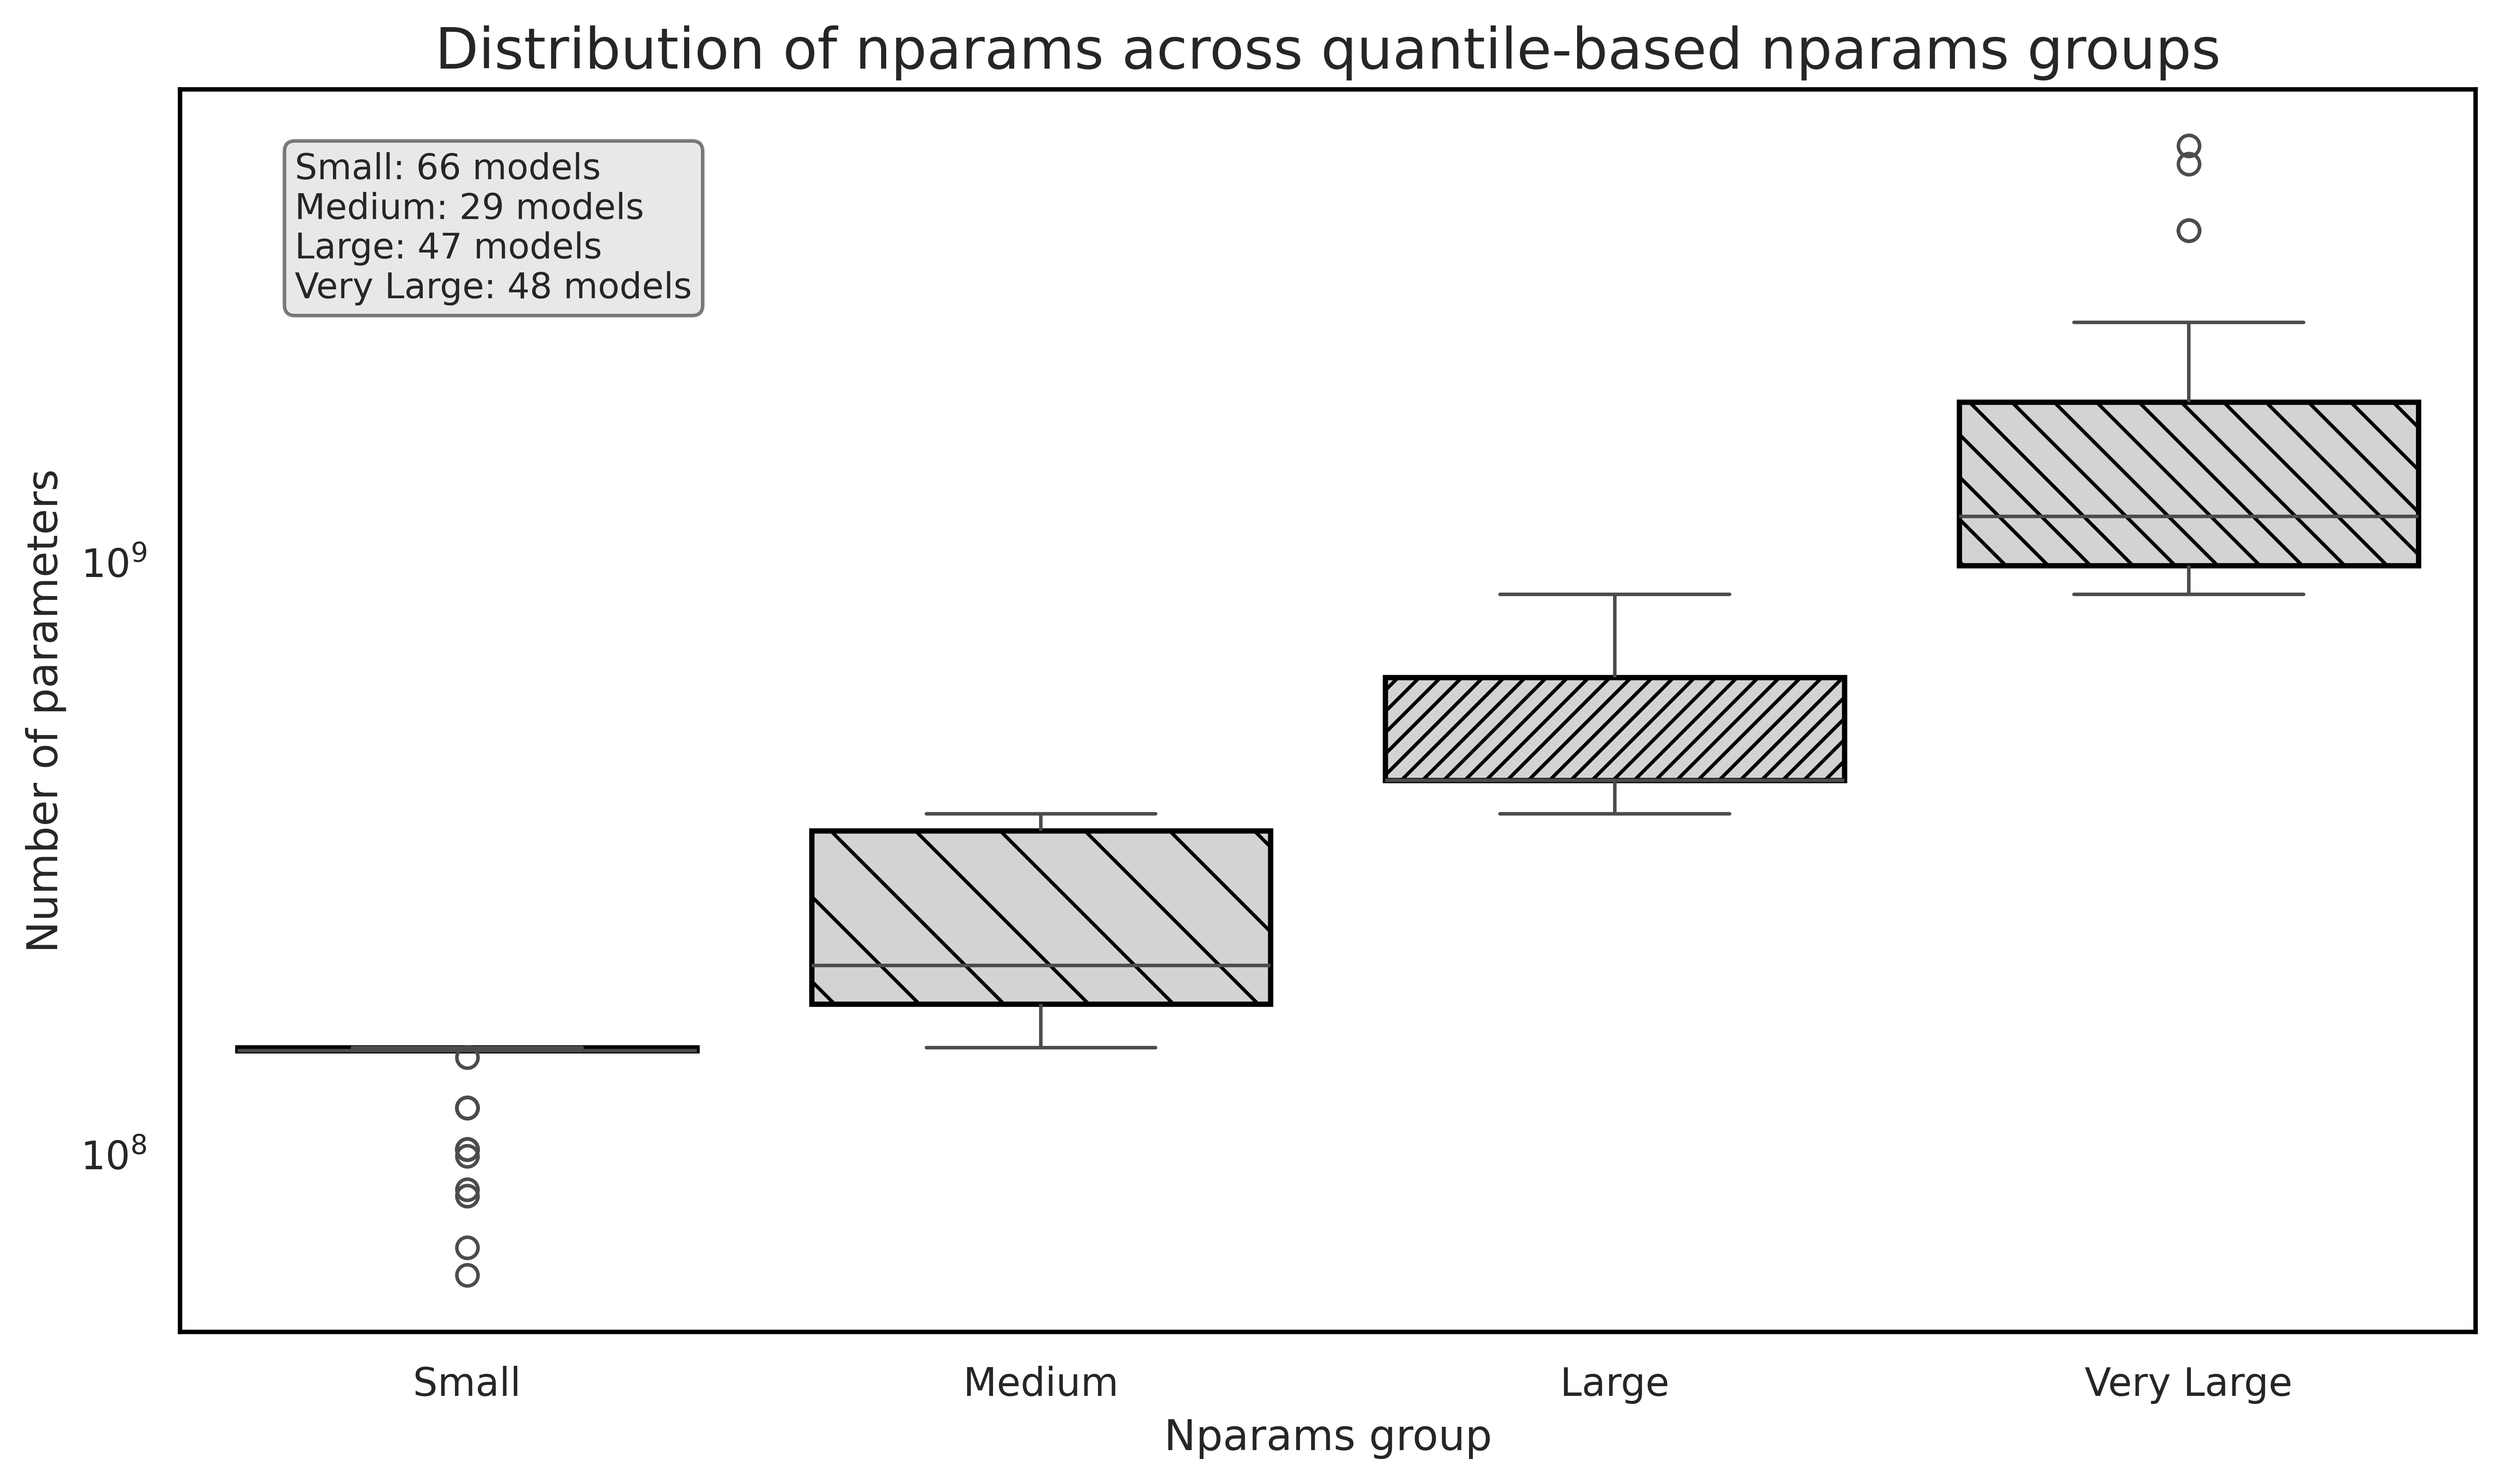

In [9]:
# Whisker plot of nparams
plt.figure(figsize=(10, 6), dpi=600)
sns.boxplot(x='nparams_group', y='nparams', data=df_nparams, order=["Small", "Medium", "Large", "Very Large"])
# Make the edges of the bars thicker
for bar in plt.gca().patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1.5)
# Make the grid lines disappear
plt.grid(False)
# Make the corners of plots color black
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
# Instead of filling the bars, use a hatch pattern unique to each bar
for i, bar in enumerate(plt.gca().patches):
    hatch_pattern = '//' if i % 2 == 0 else '\\'
    # Increase the density of the hatch pattern for higher quantiles
    hatch_pattern *= (i // 2 + 1)
    bar.set_hatch(hatch_pattern)
# Turn the colors of the bars to a light gray
for bar in plt.gca().patches:
    bar.set_facecolor('lightgray')

# Put annotation on number of models in each group in the
# top left corner of the plot
group_counts = df_nparams['nparams_group'].value_counts().to_dict()
plt.gca().annotate(f"Small: {group_counts.get('Small', 0)} models\nMedium: {group_counts.get('Medium', 0)} models\nLarge: {group_counts.get('Large', 0)} models\nVery Large: {group_counts.get('Very Large', 0)} models",
                   xy=(0.05, 0.95), xycoords='axes fraction', ha='left', va='top', fontsize=10,
                   bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='lightgray', alpha=0.5))

plt.title('Distribution of nparams across quantile-based nparams groups', fontsize=16)
plt.xlabel('Nparams group')
plt.ylabel('Number of parameters')
plt.yscale('log')
plt.tight_layout()
plt.show()

In [10]:
# Get the top 3 models with the highest number of parameters in each quantile-based group
top_models = df_nparams.groupby('nparams_group', observed=True).apply(lambda x: x.nlargest(1, 'nparams'), include_groups=False).reset_index(drop=True)
print(top_models)

           vision_model      pretrained_on     nparams
0              ViT-B-32             openai   151277313
1  ViT-B-16-SigLIP2-384              webli   375479810
2  ViT-L-16-SigLIP2-256              webli   881526786
3       EVA02-E-14-plus  laion2b_s9b_b144k  5044889089


In [11]:
# Determine the different groups of vision models
vision_model_groups = df_nparams['vision_model'].unique()
print(vision_model_groups)

['RN50' 'RN101' 'RN50x4' 'RN50x16' 'RN50x64' 'ViT-B-32' 'ViT-B-32-256'
 'ViT-B-16' 'ViT-B-16-plus-240' 'ViT-L-14' 'ViT-L-14-336' 'ViT-H-14'
 'ViT-H-14-378' 'ViT-g-14' 'ViT-bigG-14' 'roberta-ViT-B-32'
 'xlm-roberta-base-ViT-B-32' 'xlm-roberta-large-ViT-H-14' 'convnext_base'
 'convnext_base_w' 'convnext_base_w_320' 'convnext_large_d'
 'convnext_large_d_320' 'convnext_xxlarge' 'coca_ViT-B-32' 'coca_ViT-L-14'
 'EVA01-g-14' 'EVA01-g-14-plus' 'EVA02-B-16' 'EVA02-L-14' 'EVA02-L-14-336'
 'EVA02-E-14' 'EVA02-E-14-plus' 'ViT-B-16-SigLIP' 'ViT-B-16-SigLIP-256'
 'ViT-B-16-SigLIP-i18n-256' 'ViT-B-16-SigLIP-384' 'ViT-B-16-SigLIP-512'
 'ViT-L-16-SigLIP-256' 'ViT-L-16-SigLIP-384' 'ViT-SO400M-14-SigLIP'
 'ViT-SO400M-16-SigLIP-i18n-256' 'ViT-SO400M-14-SigLIP-378'
 'ViT-SO400M-14-SigLIP-384' 'ViT-B-32-SigLIP2-256' 'ViT-B-16-SigLIP2'
 'ViT-B-16-SigLIP2-256' 'ViT-B-16-SigLIP2-384' 'ViT-B-16-SigLIP2-512'
 'ViT-L-16-SigLIP2-256' 'ViT-L-16-SigLIP2-384' 'ViT-L-16-SigLIP2-512'
 'ViT-SO400M-14-SigLIP2' 'ViT-SO40

In [12]:
# Group by architecture family
# > ResNet-based (RN...) = RN50, RN101, RN50x16, RN50x64 (+ quickgelu variants)
# > ViT-based (B, L, H, g, bigG variants) only CLIP, CLIPA
# > ConvNeXt-based
# > COCA (contrastive captioners)
# > EVA (scaling-focused ViTs)
# > SigLIP / SigLIP2 variants
# > MobileCLIP
# > PE-Core
# > NLLB-CLIP
# > Misc = roberta-ViT, xlm-roberta-ViT (hybrid)

from collections import defaultdict
architecture_families = defaultdict(list)

for m in vision_model_groups:
    name = m.lower()
    if name.startswith("rn"):
        architecture_families["ResNet"].append(m)
    elif "convnext" in name:
        architecture_families["ConvNeXt"].append(m)
    elif name.startswith("coca"):
        architecture_families["COCA"].append(m)
    elif name.startswith("eva"):
        architecture_families["EVA"].append(m)
    elif "siglip2" in name:
        architecture_families["ViT-SigLIP2"].append(m)
    elif "siglip" in name:
        architecture_families["ViT-SigLIP"].append(m)
    elif "clipa" in name:
        architecture_families["ViT-CLIPA"].append(m)
    elif "worldwide" in name:
        architecture_families["ViT-Worldwide"].append(m)
    elif "vitamin" in name:
        architecture_families["ViTamin"].append(m)
    elif "pe-core" in name:
        architecture_families["PE-Core"].append(m)
    elif "mobileclip" in name:
        architecture_families["MobileCLIP"].append(m)
    elif "nllb-clip" in name:
        architecture_families["NLLB-CLIP"].append(m)
    elif "roberta" in name:
        architecture_families["Roberta-ViT"].append(m)
    elif "vit" in name:
        architecture_families["ViT"].append(m)
    else:
        architecture_families["Misc"].append(m)

# Print grouped models
total_unique_models = sum(len(mods) for mods in architecture_families.values())
print(f"Total unique vision models: {total_unique_models}")

for family, mods in architecture_families.items():
    print(f"\n{family} ({len(mods)} models):")
    print(mods)

Total unique vision models: 109

ResNet (10 models):
['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'RN50-quickgelu', 'RN101-quickgelu', 'RN50x4-quickgelu', 'RN50x16-quickgelu', 'RN50x64-quickgelu']

ViT (17 models):
['ViT-B-32', 'ViT-B-32-256', 'ViT-B-16', 'ViT-B-16-plus-240', 'ViT-L-14', 'ViT-L-14-336', 'ViT-H-14', 'ViT-H-14-378', 'ViT-g-14', 'ViT-bigG-14', 'ViT-B-32-quickgelu', 'ViT-B-16-quickgelu', 'ViT-L-14-quickgelu', 'ViT-L-14-336-quickgelu', 'ViT-H-14-quickgelu', 'ViT-H-14-378-quickgelu', 'ViT-bigG-14-quickgelu']

Roberta-ViT (3 models):
['roberta-ViT-B-32', 'xlm-roberta-base-ViT-B-32', 'xlm-roberta-large-ViT-H-14']

ConvNeXt (6 models):
['convnext_base', 'convnext_base_w', 'convnext_base_w_320', 'convnext_large_d', 'convnext_large_d_320', 'convnext_xxlarge']

COCA (2 models):
['coca_ViT-B-32', 'coca_ViT-L-14']

EVA (7 models):
['EVA01-g-14', 'EVA01-g-14-plus', 'EVA02-B-16', 'EVA02-L-14', 'EVA02-L-14-336', 'EVA02-E-14', 'EVA02-E-14-plus']

ViT-SigLIP (13 models):
['ViT-B-16-

In [13]:
# Use the architecture families to create a new column in df_nparams
def get_architecture_family(vision_model):
    for family, mods in architecture_families.items():
        if vision_model in mods:
            return family
    return "Unknown"

df_nparams['architecture_family'] = df_nparams['vision_model'].apply(get_architecture_family)
df_nparams

,vision_model,pretrained_on,nparams,nparams_group,architecture_family
0,RN50,openai,102007137,Small,ResNet
1,RN50,yfcc15m,102007137,Small,ResNet
2,RN50,cc12m,102007137,Small,ResNet
3,RN101,openai,119688033,Small,ResNet
4,RN101,yfcc15m,119688033,Small,ResNet
...,...,...,...,...,...
185,ViT-H-14-quickgelu,metaclip_fullcc,986109441,Very Large,ViT
186,ViT-H-14-quickgelu,dfn5b,986109441,Very Large,ViT
187,ViT-H-14-378-quickgelu,dfn5b,986714881,Very Large,ViT
188,ViT-bigG-14-quickgelu,metaclip_fullcc,2539567105,Very Large,ViT


In [14]:
len(df_nparams['architecture_family'].unique())

14

In [15]:
macro_cmc_files = [f for f in os.listdir(macro_cmc_results) if f.endswith(".json")]

def extract_macro_cmc(data):
    mean_macro_cmc_k_5 = 0
    mean_macro_cmc_k_3 = 0
    mean_macro_cmc_k_1 = 0

    for record in data:
        mean_macro_cmc_k_5 += data[record]["@k=5"]
        mean_macro_cmc_k_3 += data[record]["@k=3"]
        mean_macro_cmc_k_1 += data[record]["@k=1"]
    mean_macro_cmc_k_5 /= len(data)
    mean_macro_cmc_k_3 /= len(data)
    mean_macro_cmc_k_1 /= len(data)
    return mean_macro_cmc_k_5, mean_macro_cmc_k_3, mean_macro_cmc_k_1

for_df_macro_cmc = defaultdict(list)

for file in macro_cmc_files:
    with open(os.path.join(macro_cmc_results, file), "r") as f:
        data = json.load(f)
    mean_macro_cmc_k_5, mean_macro_cmc_k_3, mean_macro_cmc_k_1 = extract_macro_cmc(data)

    if "--" in file:
        parts = file.replace("macro_CMC_", "").replace(".json", "").split("--")
        vision_model = parts[0]
        pretrained_on = parts[1]
    else:
        continue

    for_df_macro_cmc["vision_model"].append(vision_model)
    for_df_macro_cmc["pretrained_on"].append(pretrained_on)
    for_df_macro_cmc["mean_macro_cmc@5"].append(mean_macro_cmc_k_5)
    for_df_macro_cmc["mean_macro_cmc@3"].append(mean_macro_cmc_k_3)
    for_df_macro_cmc["mean_macro_cmc@1"].append(mean_macro_cmc_k_1)

df_macro_cmc = pd.DataFrame(for_df_macro_cmc)

# Combine df_macro_cmc with df_nparams
df_combined = pd.merge(df_nparams, df_macro_cmc, on=["vision_model", "pretrained_on"], how="inner")
df_combined

,vision_model,pretrained_on,nparams,nparams_group,architecture_family,mean_macro_cmc@5,mean_macro_cmc@3,mean_macro_cmc@1
0,RN50,openai,102007137,Small,ResNet,0.592958,0.538891,0.374284
1,RN50,yfcc15m,102007137,Small,ResNet,0.058329,0.038877,0.015576
2,RN50,cc12m,102007137,Small,ResNet,0.045844,0.030347,0.011492
3,RN101,openai,119688033,Small,ResNet,0.644727,0.583606,0.410046
4,RN101,yfcc15m,119688033,Small,ResNet,0.079587,0.054703,0.022599
...,...,...,...,...,...,...,...,...
185,ViT-H-14-quickgelu,metaclip_fullcc,986109441,Very Large,ViT,0.839395,0.796056,0.608017
186,ViT-H-14-quickgelu,dfn5b,986109441,Very Large,ViT,0.793056,0.742255,0.564158
187,ViT-H-14-378-quickgelu,dfn5b,986714881,Very Large,ViT,0.792628,0.744358,0.563767
188,ViT-bigG-14-quickgelu,metaclip_fullcc,2539567105,Very Large,ViT,0.844122,0.806810,0.625752


In [16]:
micro_cmc_files = [f for f in os.listdir(micro_cmc_results) if f.endswith(".json")]

for_df_micro_cmc = defaultdict(list)

for file in micro_cmc_files:
    with open(os.path.join(micro_cmc_results, file), "r") as f:
        data = json.load(f)

    mean_micro_cmc_k_5 = data["@k=5"]
    mean_micro_cmc_k_3 = data["@k=3"]
    mean_micro_cmc_k_1 = data["@k=1"]

    if "--" in file:
        parts = file.replace("micro_CMC_", "").replace(".json", "").split("--")
        vision_model = parts[0]
        pretrained_on = parts[1]
    else:
        continue

    for_df_micro_cmc["vision_model"].append(vision_model)
    for_df_micro_cmc["pretrained_on"].append(pretrained_on)
    for_df_micro_cmc["mean_micro_cmc@5"].append(mean_micro_cmc_k_5)
    for_df_micro_cmc["mean_micro_cmc@3"].append(mean_micro_cmc_k_3)
    for_df_micro_cmc["mean_micro_cmc@1"].append(mean_micro_cmc_k_1)

df_micro_cmc = pd.DataFrame(for_df_micro_cmc)
# Combine df_micro_cmc with df_combined
df_combined = pd.merge(df_combined, df_micro_cmc, on=["vision_model", "pretrained_on"], how="inner")
df_combined

,vision_model,pretrained_on,nparams,nparams_group,architecture_family,mean_macro_cmc@5,mean_macro_cmc@3,mean_macro_cmc@1,mean_micro_cmc@5,mean_micro_cmc@3,mean_micro_cmc@1
0,RN50,openai,102007137,Small,ResNet,0.592958,0.538891,0.374284,0.637053,0.581960,0.404814
1,RN50,yfcc15m,102007137,Small,ResNet,0.058329,0.038877,0.015576,0.065597,0.044153,0.018089
2,RN50,cc12m,102007137,Small,ResNet,0.045844,0.030347,0.011492,0.052614,0.035108,0.014248
3,RN101,openai,119688033,Small,ResNet,0.644727,0.583606,0.410046,0.684415,0.624362,0.438415
4,RN101,yfcc15m,119688033,Small,ResNet,0.079587,0.054703,0.022599,0.089521,0.062436,0.026939
...,...,...,...,...,...,...,...,...,...,...,...
185,ViT-H-14-quickgelu,metaclip_fullcc,986109441,Very Large,ViT,0.839395,0.796056,0.608017,0.873620,0.831802,0.646487
186,ViT-H-14-quickgelu,dfn5b,986109441,Very Large,ViT,0.793056,0.742255,0.564158,0.831072,0.785801,0.603258
187,ViT-H-14-378-quickgelu,dfn5b,986714881,Very Large,ViT,0.792628,0.744358,0.563767,0.833406,0.789643,0.603598
188,ViT-bigG-14-quickgelu,metaclip_fullcc,2539567105,Very Large,ViT,0.844122,0.806810,0.625752,0.876197,0.840457,0.659227


In [17]:
# Export the combined dataframe to a CSV file
output_csv = os.path.join(results_dir, "model_nparams_cmc_summary.csv")
df_combined.to_csv(output_csv, index=False)

In [18]:
# Determine the count of models per architecture family
df_combined['architecture_family'].value_counts()

architecture_family
ViT              80
ResNet           16
ViT-SigLIP2      15
ViTamin          15
ViT-SigLIP       15
ConvNeXt         12
EVA               7
ViT-CLIPA         7
ViT-Worldwide     5
PE-Core           5
MobileCLIP        4
COCA              4
Roberta-ViT       3
NLLB-CLIP         2
Name: count, dtype: int64

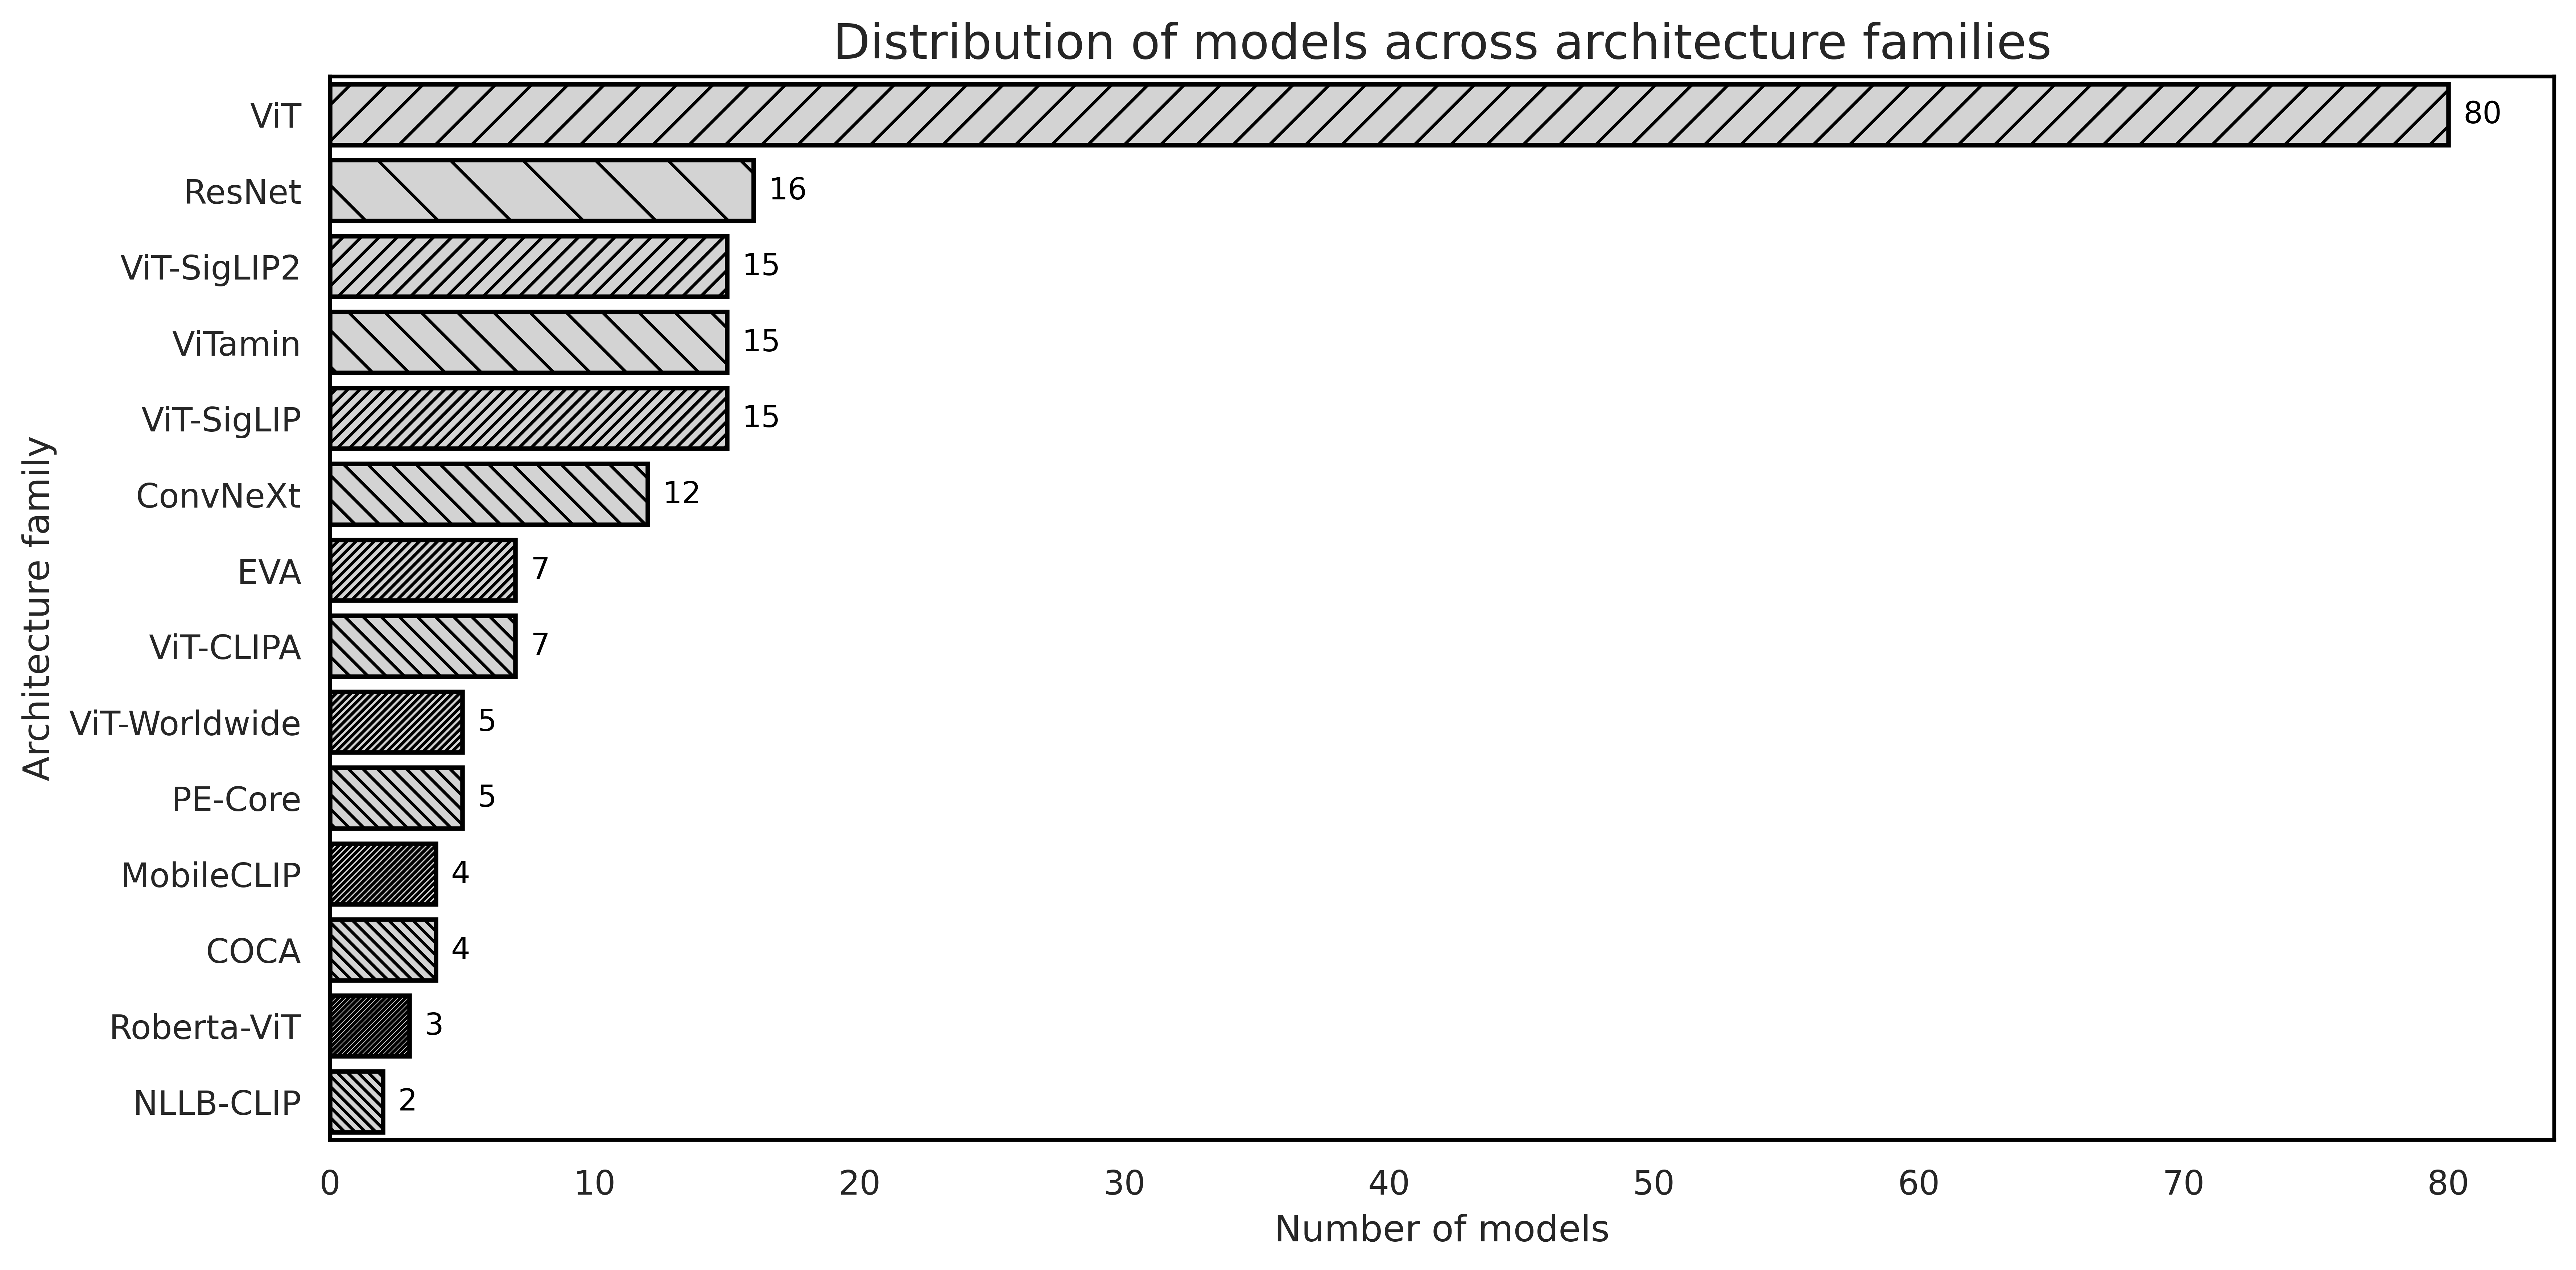

In [19]:
# Bar plot of the number of models per architecture family
plt.figure(figsize=(12, 6), dpi=600)
sns.countplot(y='architecture_family', data=df_combined, order=df_combined['architecture_family'].value_counts().index)
# Make the edges of the bars thicker
for bar in plt.gca().patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1.5)
# Make the grid lines disappear
plt.grid(False)
# Make the corners of plots color black
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
# Add value labels on top of each bar make it integer
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_width())}', (p.get_x() + p.get_width(), p.get_y() + p.get_height() / 2.), 
                       ha='left', va='center', fontsize=10, color='black', xytext=(5, 0),
                       textcoords='offset points')
# Instead of filling the bars, use a hatch pattern unique to each bar
for i, bar in enumerate(plt.gca().patches):
    hatch_pattern = '//' if i % 2 == 0 else '\\'
    # Increase the density of the hatch pattern for higher counts
    hatch_pattern *= (i // 2 + 1)
    bar.set_hatch(hatch_pattern)
# Turn the colors of the bars to a light gray
for bar in plt.gca().patches:
    bar.set_facecolor('lightgray')
plt.title('Distribution of models across architecture families', fontsize=16)
plt.xlabel('Number of models')
plt.ylabel('Architecture family')
plt.tight_layout()
plt.show()

In [20]:
df = df_combined.copy()

df['log10_nparams'] = np.log10(df['nparams'].astype(float))

# Helper to sort architecture names by frequency
arch_counts = df['architecture_family'].value_counts()
arch_order = arch_counts.index.tolist()

# 1) Architecture prevalence
arch_table = (
    df.groupby('architecture_family')
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
      .reset_index(drop=True)
)
display(arch_table)

# 2) Parameter scale distribution + crosstab with architecture
size_table = (
    df.groupby('nparams_group')
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
      .reset_index(drop=True)
)
display(size_table)

crosstab_arch_size = pd.crosstab(df['architecture_family'], df['nparams_group'])
# Sort rows by total count desc, columns by size_table order if possible
crosstab_arch_size = crosstab_arch_size.loc[arch_order]
display(crosstab_arch_size)

# 3) Performance vs. parameters (correlations + plots)
metrics = ['mean_macro_cmc@1', 'mean_macro_cmc@3', 'mean_macro_cmc@5',
           'mean_micro_cmc@1', 'mean_micro_cmc@3', 'mean_micro_cmc@5']

corr_summary = []
for m in metrics:
    pear = df['log10_nparams'].corr(df[m], method='pearson')
    spear = df['log10_nparams'].corr(df[m], method='spearman')
    corr_summary.append({'metric': m, 'pearson_log10nparams': pear, 'spearman_log10nparams': spear})
corr_table = pd.DataFrame(corr_summary).sort_values('metric')
display(corr_table)

# Scatter + trendline plots (each as a single plot)
def scatter_with_trend(x, y, xlabel, ylabel, title, outfile):
    plt.figure()
    plt.scatter(x, y, alpha=0.6)
    # Trendline (1st-degree poly)
    coeffs = np.polyfit(x, y, deg=1)
    xfit = np.linspace(np.min(x), np.max(x), 200)
    yfit = coeffs[0] * xfit + coeffs[1]
    plt.plot(xfit, yfit)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.close()

scatter_with_trend(df['log10_nparams'], df['mean_macro_cmc@1'],
                   "log10(# parameters)", "mean_macro_cmc@1",
                   "Performance vs Size (Macro@1)", "/mnt/data/scatter_macro1.png")

scatter_with_trend(df['log10_nparams'], df['mean_micro_cmc@1'],
                   "log10(# parameters)", "mean_micro_cmc@1",
                   "Performance vs Size (Micro@1)", "/mnt/data/scatter_micro1.png")

scatter_with_trend(df['log10_nparams'], df['mean_macro_cmc@5'],
                   "log10(# parameters)", "mean_macro_cmc@5",
                   "Performance vs Size (Macro@5)", "/mnt/data/scatter_macro5.png")

# 4) Macro vs Micro by architecture & size
arch_perf = (df
             .groupby('architecture_family')[['mean_macro_cmc@1','mean_micro_cmc@1']]
             .mean()
             .reset_index()
             .sort_values('mean_macro_cmc@1', ascending=False))
arch_perf['count'] = df.groupby('architecture_family').size().reindex(arch_perf['architecture_family']).values
display(arch_perf)

size_perf = (df
             .groupby('nparams_group')[['mean_macro_cmc@1','mean_micro_cmc@1']]
             .mean()
             .reset_index()
             .sort_values('mean_macro_cmc@1', ascending=False))
size_perf['count'] = df.groupby('nparams_group').size().reindex(size_perf['nparams_group']).values
display(size_perf)

# 5) Pretraining dataset effect (only show datasets with >= 5 models to ensure stability)
pretrain_counts = df['pretrained_on'].value_counts()
valid_pretrains = pretrain_counts[pretrain_counts >= 5].index
pretrain_perf = (df[df['pretrained_on'].isin(valid_pretrains)]
                 .groupby('pretrained_on')[['mean_macro_cmc@1','mean_micro_cmc@1']]
                 .agg(['mean','std','count']))
pretrain_perf.columns = ['_'.join(col).strip() for col in pretrain_perf.columns.values]
pretrain_perf = pretrain_perf.sort_values('mean_macro_cmc@1_mean', ascending=False).reset_index()
display(pretrain_perf)

# 6) Leaderboards
leader_macro1 = (df[['vision_model','architecture_family','nparams','nparams_group','pretrained_on','mean_macro_cmc@1']]
                 .sort_values('mean_macro_cmc@1', ascending=False)
                 .head(25)
                 .reset_index(drop=True))
display(leader_macro1)

leader_micro1 = (df[['vision_model','architecture_family','nparams','nparams_group','pretrained_on','mean_micro_cmc@1']]
                 .sort_values('mean_micro_cmc@1', ascending=False)
                 .head(25)
                 .reset_index(drop=True))
display(leader_micro1)

# 7) Save a compact CSV summary for download
summary_cols = [
    'vision_model','architecture_family','pretrained_on','nparams','nparams_group',
    'mean_macro_cmc@1','mean_macro_cmc@3','mean_macro_cmc@5',
    'mean_micro_cmc@1','mean_micro_cmc@3','mean_micro_cmc@5','log10_nparams'
]

# Create a brief text summary with key stats
text_report = []

# Most common architecture
most_common_arch = arch_table.iloc[0]['architecture_family']
most_common_arch_count = int(arch_table.iloc[0]['count'])
text_report.append(f"Most common architecture: {most_common_arch} ({most_common_arch_count} models)")

# Size group with most models
top_size = size_table.iloc[0]['nparams_group']
top_size_count = int(size_table.iloc[0]['count'])
text_report.append(f"Most common size group: {top_size} ({top_size_count} models)")

# Correlation highlights
corr_macro1 = corr_table.loc[corr_table['metric']=='mean_macro_cmc@1', ['pearson_log10nparams','spearman_log10nparams']].iloc[0].to_dict()
text_report.append(f"Correlation (log10 params vs Macro@1): Pearson={corr_macro1['pearson_log10nparams']:.3f}, Spearman={corr_macro1['spearman_log10nparams']:.3f}")

# Best model by macro@1
best_macro1_row = df.loc[df['mean_macro_cmc@1'].idxmax()]
text_report.append(f"Top Macro@1 model: {best_macro1_row['vision_model']} (arch={best_macro1_row['architecture_family']}, params={best_macro1_row['nparams']}, Macro@1={best_macro1_row['mean_macro_cmc@1']:.4f})")

# Best model by micro@1
best_micro1_row = df.loc[df['mean_micro_cmc@1'].idxmax()]
text_report.append(f"Top Micro@1 model: {best_micro1_row['vision_model']} (arch={best_micro1_row['architecture_family']}, params={best_micro1_row['nparams']}, Micro@1={best_micro1_row['mean_micro_cmc@1']:.4f})")

,architecture_family,count
0,ViT,80
1,ResNet,16
2,ViT-SigLIP,15
3,ViT-SigLIP2,15
4,ViTamin,15
5,ConvNeXt,12
6,EVA,7
7,ViT-CLIPA,7
8,ViT-Worldwide,5
9,PE-Core,5


/tmp/ipykernel_2607782/3820830248.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('nparams_group')


,nparams_group,count
0,Small,66
1,Very Large,48
2,Large,47
3,Medium,29


nparams_group,Small,Medium,Large,Very Large
architecture_family,,,,
ViT,46,3,18,13
ResNet,10,4,2,0
ViT-SigLIP2,0,3,3,9
ViTamin,3,1,8,3
ViT-SigLIP,0,5,7,3
ConvNeXt,0,9,0,3
EVA,1,0,2,4
ViT-CLIPA,0,0,2,5
ViT-Worldwide,0,0,0,5


,metric,pearson_log10nparams,spearman_log10nparams
0,mean_macro_cmc@1,0.647929,0.740616
1,mean_macro_cmc@3,0.603996,0.747865
2,mean_macro_cmc@5,0.583224,0.751870
3,mean_micro_cmc@1,0.633752,0.737575
4,mean_micro_cmc@3,0.583739,0.744778
5,mean_micro_cmc@5,0.561435,0.746274


...

/tmp/ipykernel_2607782/3820830248.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('nparams_group')[['mean_macro_cmc@1','mean_micro_cmc@1']]
/tmp/ipykernel_2607782/3820830248.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_perf['count'] = df.groupby('nparams_group').size().reindex(size_perf['nparams_group']).values


,nparams_group,mean_macro_cmc@1,mean_micro_cmc@1,count
3,Very Large,0.622571,0.654632,48
2,Large,0.565482,0.599371,47
1,Medium,0.481675,0.515563,29
0,Small,0.297959,0.321795,66


,pretrained_on,mean_macro_cmc@1_mean,mean_macro_cmc@1_std,mean_macro_cmc@1_count,mean_micro_cmc@1_mean,mean_micro_cmc@1_std,mean_micro_cmc@1_count
0,webli,0.635833,0.073618,26,0.667187,0.069718,26
1,metaclip2_worldwide,0.626373,0.012674,5,0.655716,0.012715,5
2,datacomp1b,0.605484,0.087141,21,0.637414,0.085959,21
3,meta,0.533568,0.218668,5,0.561157,0.219455,5
4,metaclip_fullcc,0.528849,0.094300,10,0.565621,0.096138,10
5,laion400m_e32,0.466857,0.054809,5,0.502465,0.058411,5
6,laion400m_e31,0.466393,0.054515,5,0.502154,0.058225,5
7,metaclip_400m,0.439288,0.076748,6,0.473410,0.079328,6
8,openai,0.427319,0.068589,18,0.459284,0.069732,18


,vision_model,architecture_family,nparams,nparams_group,pretrained_on,mean_macro_cmc@1
0,ViT-gopt-16-SigLIP2-384,ViT-SigLIP2,1871885426,Very Large,webli,0.744512
1,ViT-gopt-16-SigLIP2-256,ViT-SigLIP2,1871393906,Very Large,webli,0.736296
2,PE-Core-L-14-336,PE-Core,671138817,Large,meta,0.728505
3,ViT-SO400M-14-SigLIP2-378,ViT-SigLIP2,1136008498,Very Large,webli,0.725418
4,ViT-SO400M-16-SigLIP2-512,ViT-SigLIP2,1136555698,Very Large,webli,0.723414
5,ViT-SO400M-16-SigLIP2-384,ViT-SigLIP2,1136039602,Very Large,webli,0.721747
6,ViT-SO400M-16-SigLIP2-256,ViT-SigLIP2,1135670962,Very Large,webli,0.708589
7,EVA02-E-14-plus,EVA,5044889089,Very Large,laion2b_s9b_b144k,0.705938
8,PE-Core-bigG-14-448,PE-Core,2419267841,Very Large,meta,0.704361
9,ViT-SO400M-14-SigLIP2,ViT-SigLIP2,1135463602,Very Large,webli,0.701484


,vision_model,architecture_family,nparams,nparams_group,pretrained_on,mean_micro_cmc@1
0,ViT-gopt-16-SigLIP2-384,ViT-SigLIP2,1871885426,Very Large,webli,0.769949
1,ViT-gopt-16-SigLIP2-256,ViT-SigLIP2,1871393906,Very Large,webli,0.763433
2,PE-Core-L-14-336,PE-Core,671138817,Large,meta,0.757792
3,ViT-SO400M-14-SigLIP2-378,ViT-SigLIP2,1136008498,Very Large,webli,0.749331
4,ViT-SO400M-16-SigLIP2-512,ViT-SigLIP2,1136555698,Very Large,webli,0.748651
5,ViT-SO400M-16-SigLIP2-384,ViT-SigLIP2,1136039602,Very Large,webli,0.745733
6,EVA02-E-14-plus,EVA,5044889089,Very Large,laion2b_s9b_b144k,0.738147
7,ViT-SO400M-16-SigLIP2-256,ViT-SigLIP2,1135670962,Very Large,webli,0.732458
8,ViT-SO400M-14-SigLIP2,ViT-SigLIP2,1135463602,Very Large,webli,0.725991
9,PE-Core-bigG-14-448,PE-Core,2419267841,Very Large,meta,0.724678


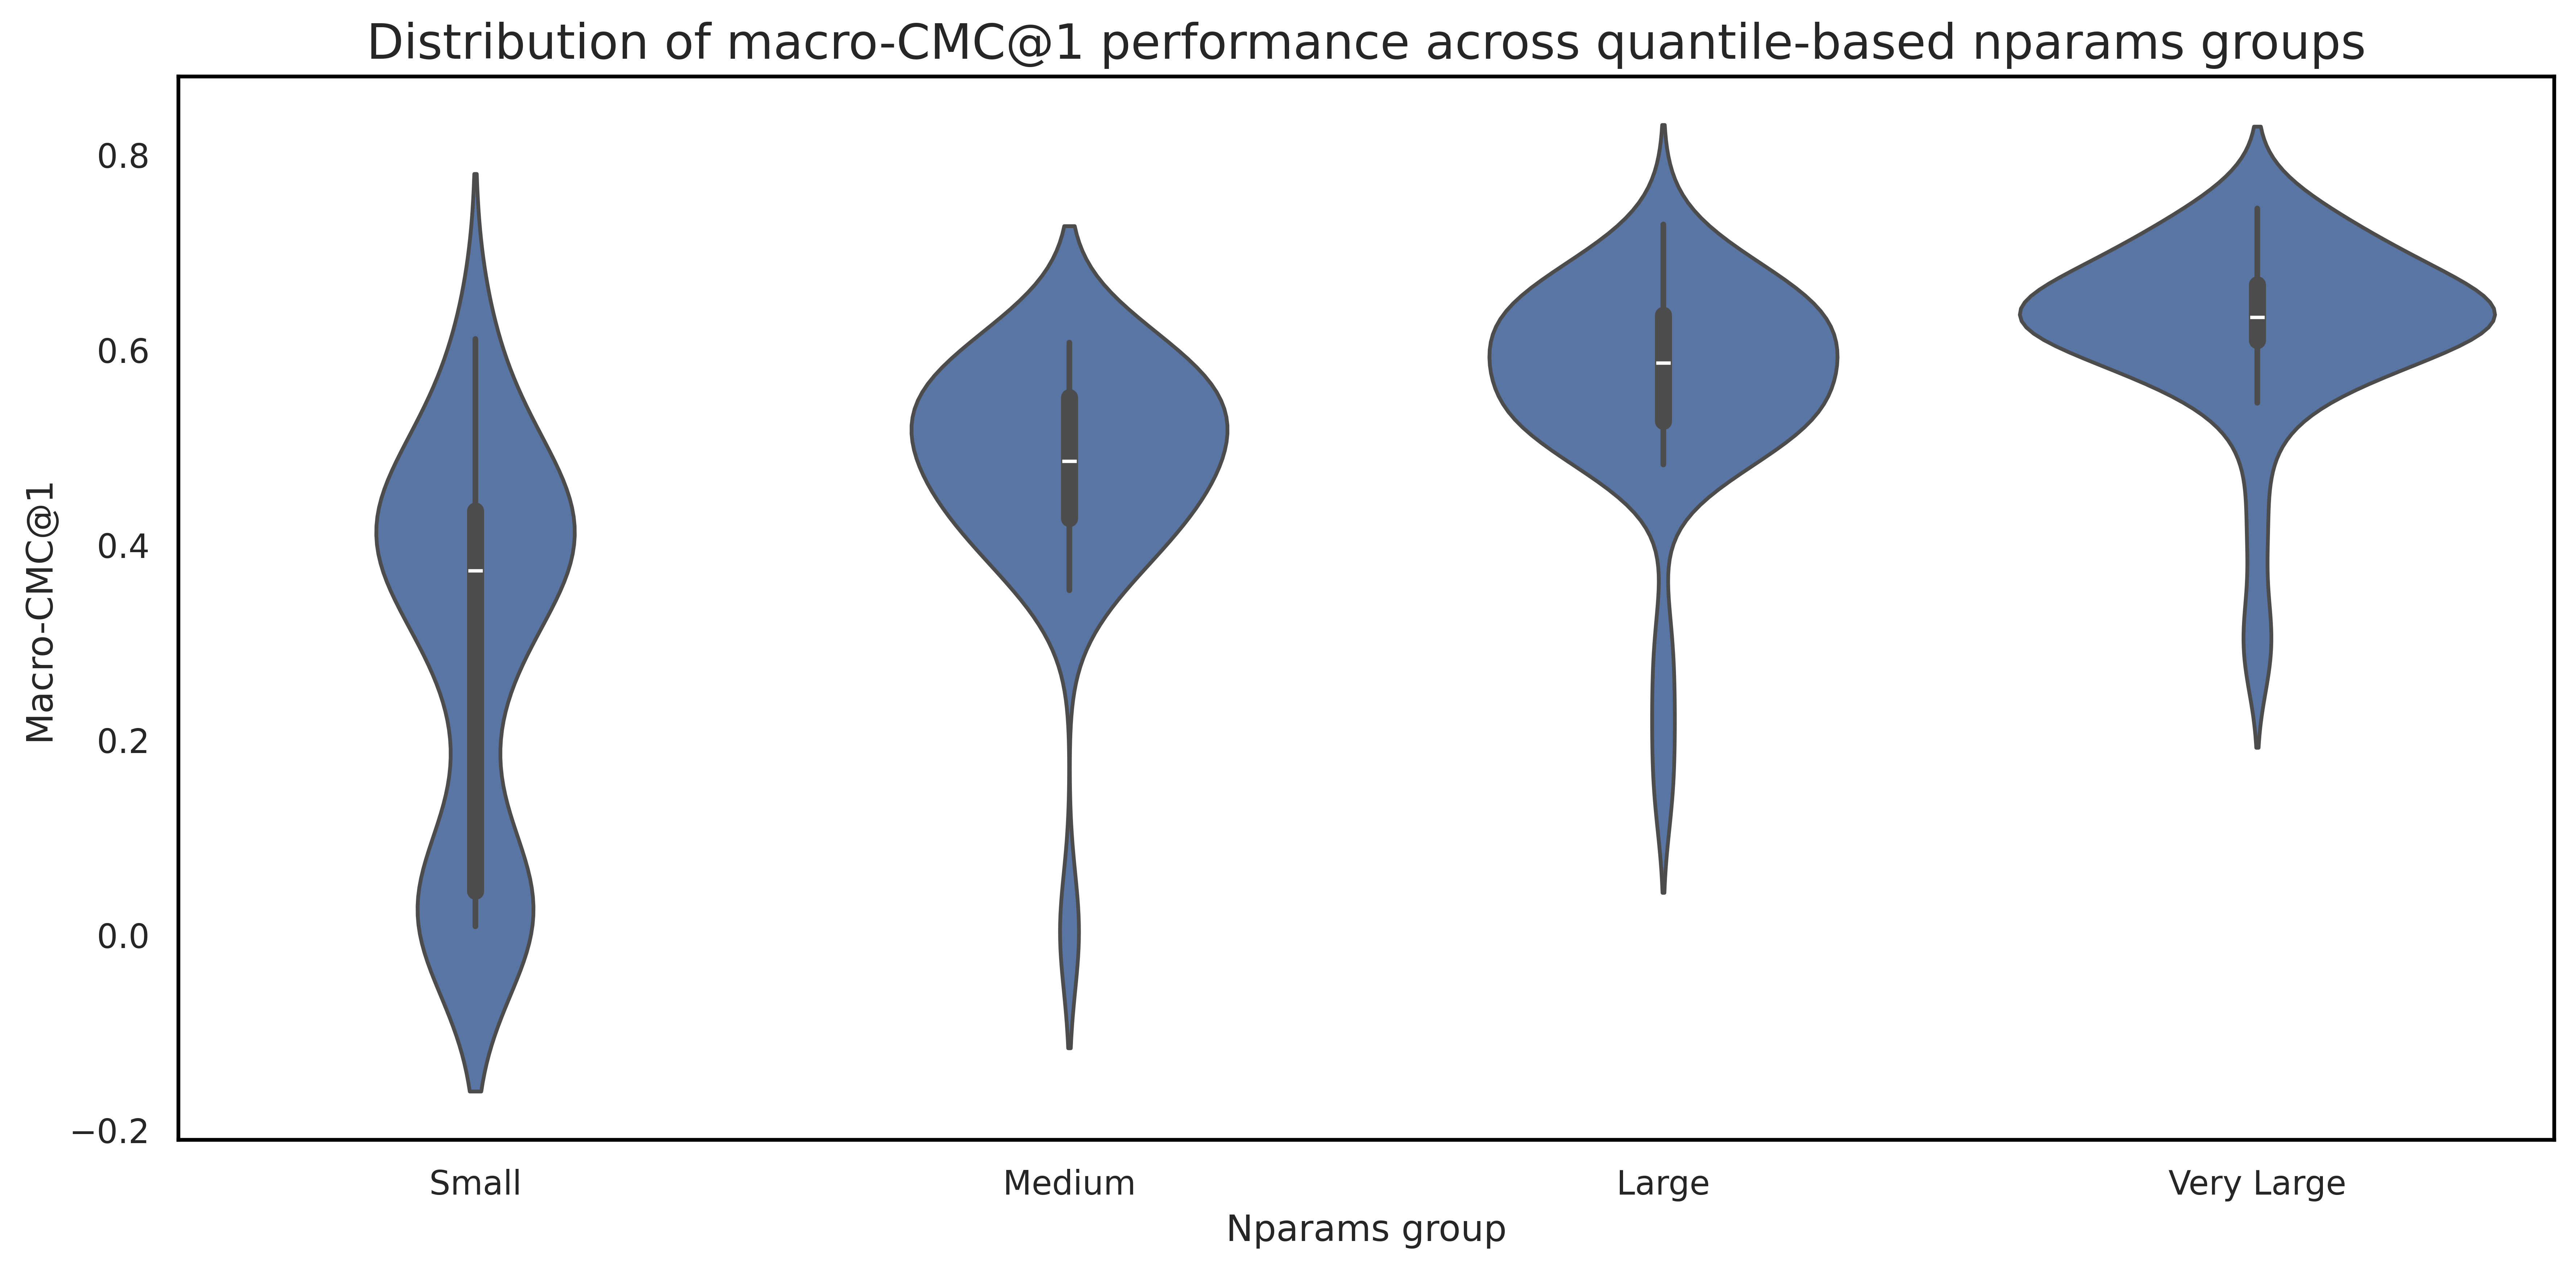

In [23]:
# Violin plot of small, medium, large, very large groups and their performance
plt.figure(figsize=(12, 6), dpi=600)
sns.violinplot(x='nparams_group', y='mean_macro_cmc@1',
                data=df, order=["Small", "Medium", "Large", "Very Large"])
# Make the edges of the bars thicker
for bar in plt.gca().patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1.5)
# Make the grid lines disappear
plt.grid(False)
# Make the corners of plots color black
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
# Instead of filling the bars, use a hatch pattern unique to each bar
for i, bar in enumerate(plt.gca().patches):
    hatch_pattern = '//' if i % 2 == 0 else '\\'
    # Increase the density of the hatch pattern for higher quantiles
    hatch_pattern *= (i // 2 + 1)
    bar.set_hatch(hatch_pattern)
# Turn the colors of the bars to a light gray
for bar in plt.gca().patches:
    bar.set_facecolor('lightgray')
plt.title('Distribution of macro-CMC@1 performance across quantile-based nparams groups', fontsize=16)
plt.xlabel('Nparams group')
plt.ylabel('Macro-CMC@1')
plt.tight_layout()
plt.show()

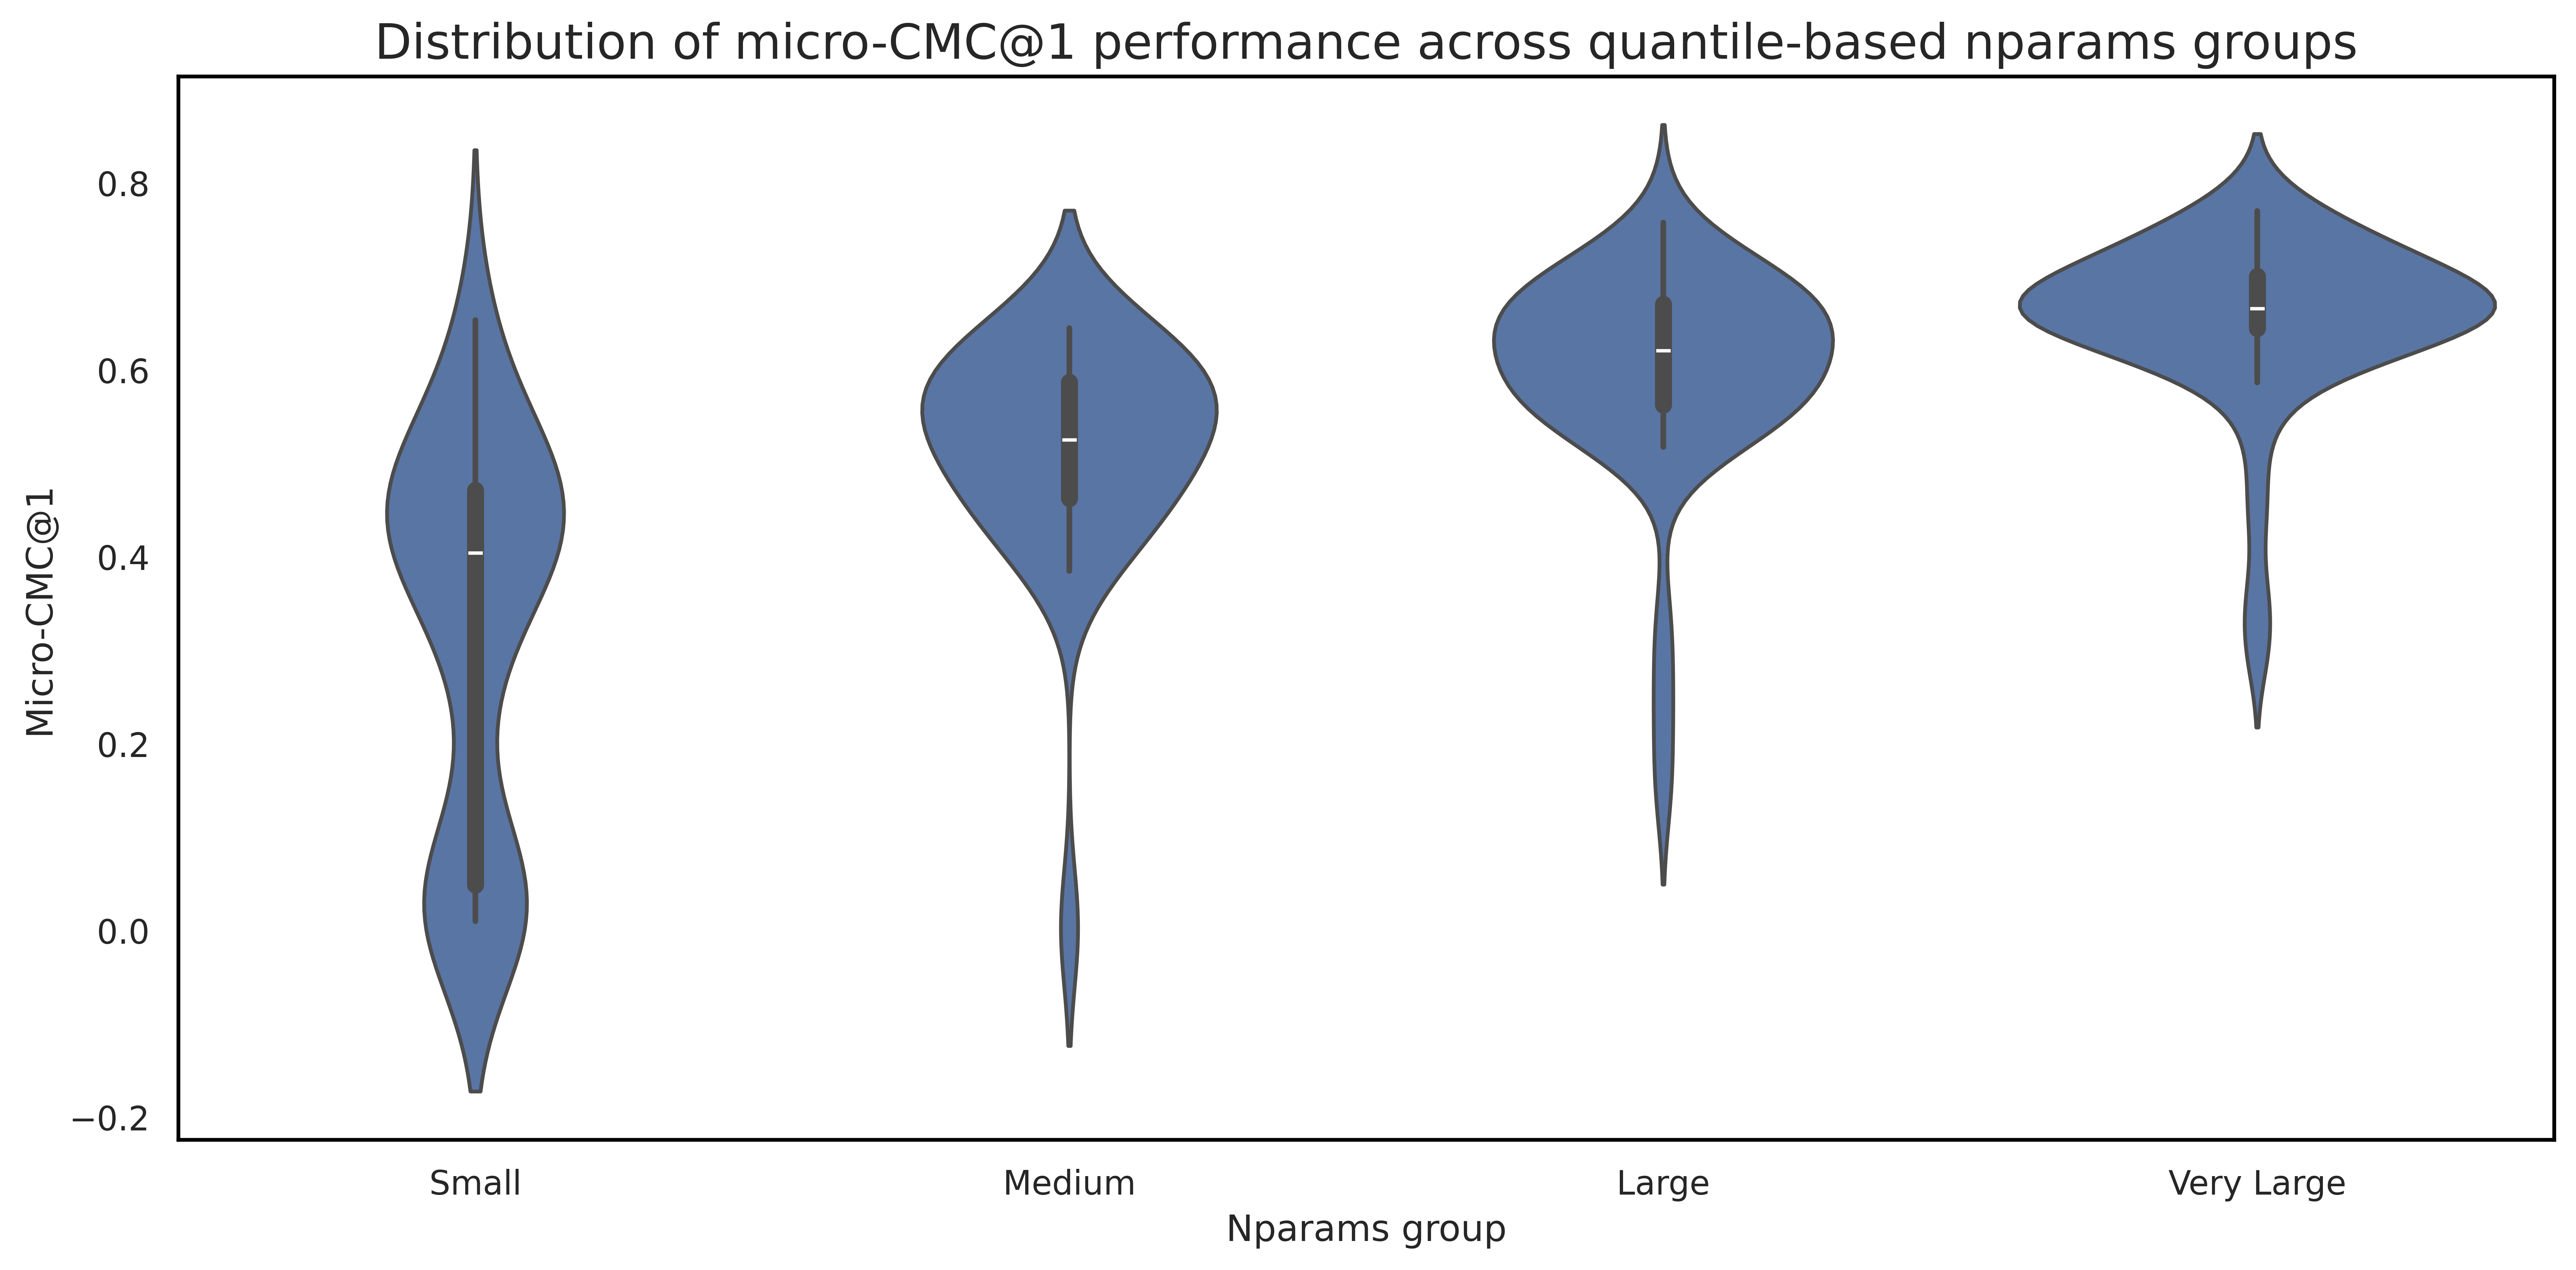

In [24]:
# Violin plot of small, medium, large, very large groups and their performance
plt.figure(figsize=(12, 6), dpi=600)
sns.violinplot(x='nparams_group', y='mean_micro_cmc@1',
                data=df, order=["Small", "Medium", "Large", "Very Large"])
# Make the edges of the bars thicker
for bar in plt.gca().patches:
    bar.set_edgecolor('black')
    bar.set_linewidth(1.5)
# Make the grid lines disappear
plt.grid(False)
# Make the corners of plots color black
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
# Instead of filling the bars, use a hatch pattern unique to each bar
for i, bar in enumerate(plt.gca().patches):
    hatch_pattern = '//' if i % 2 == 0 else '\\'
    # Increase the density of the hatch pattern for higher quantiles
    hatch_pattern *= (i // 2 + 1)
    bar.set_hatch(hatch_pattern)
# Turn the colors of the bars to a light gray
for bar in plt.gca().patches:
    bar.set_facecolor('lightgray')
plt.title('Distribution of micro-CMC@1 performance across quantile-based nparams groups', fontsize=16)
plt.xlabel('Nparams group')
plt.ylabel('Micro-CMC@1')
plt.tight_layout()
plt.show()

In [ ]:
dataset_perf = df.groupby("pretrained_on")[
    ["mean_macro_cmc@1", "mean_macro_cmc@3", "mean_macro_cmc@5",
     "mean_micro_cmc@1", "mean_micro_cmc@3", "mean_micro_cmc@5"]
].mean().reset_index()

# Add an overall average score per dataset (across all metrics)
dataset_perf["overall_mean_cmc"] = dataset_perf[[
    "mean_macro_cmc@1", "mean_macro_cmc@3", "mean_macro_cmc@5",
    "mean_micro_cmc@1", "mean_micro_cmc@3", "mean_micro_cmc@5"
]].mean(axis=1)

# Step 2: Identify weak datasets (e.g., bottom 70% in terms of overall mean CMC)
threshold = dataset_perf["overall_mean_cmc"].quantile(0.70)
weak_datasets = dataset_perf[dataset_perf["overall_mean_cmc"] <= threshold]["pretrained_on"].tolist()
strong_datasets = dataset_perf[dataset_perf["overall_mean_cmc"] > threshold]["pretrained_on"].tolist()

# Step 3: Recompute correlations (Pearson & Spearman) only for strong datasets
results_filtered = []
for group, gdata in df[df["pretrained_on"].isin(strong_datasets)].groupby("pretrained_on"):
    if gdata.shape[0] >= 4:
        log_params = np.log10(gdata["nparams"])
        for metric in ["mean_macro_cmc@1", "mean_macro_cmc@3", "mean_macro_cmc@5",
                       "mean_micro_cmc@1", "mean_micro_cmc@3", "mean_micro_cmc@5"]:
            pearson_corr = log_params.corr(gdata[metric], method="pearson")
            spearman_corr = log_params.corr(gdata[metric], method="spearman")
            results_filtered.append({
                "pretrained_on": group,
                "metric": metric,
                "pearson_log10nparams": pearson_corr,
                "spearman_log10nparams": spearman_corr,
                "n_models": gdata.shape[0]
            })

results_filtered_df = pd.DataFrame(results_filtered)
print("\nFiltered Correlation Results (strong datasets only) unique pretrained_on:")
print(results_filtered_df['pretrained_on'].unique())
print(f"threshold: {threshold}")

In [ ]:
threshold

In [ ]:
results_filtered_df

In [ ]:
# Sort by pearson and spearman of macro@1 descending
# Filter all positive correlations
results_df = results_filtered_df[(results_filtered_df["pearson_log10nparams"] > 0) & (results_filtered_df["spearman_log10nparams"] > 0)]
results_df = results_df.sort_values(by=["pearson_log10nparams", "spearman_log10nparams"], ascending=False)

display(results_df)

In [ ]:
df

In [ ]:
# Sort by mean_macro_cmc@1 descending
df_sorted = df.sort_values(by="mean_macro_cmc@1", ascending=False).reset_index(drop=True)
df_sorted = df_sorted[df_sorted["mean_macro_cmc@1"] >= 0.60]
high_quality_dsets = df_sorted['pretrained_on'].unique()
print(f"High quality datasets (mean_macro_cmc@1 >= 0.60): {high_quality_dsets}")

In [ ]:
df_sorted